
sigma0

110-300
2023 27.157876306793437
2024 27.130848287127673
2025 27.21737913645145
change
{'2024-2023': np.float64(-0.027028019665763736), '2025-2024': np.float64(0.08653084932377553)}

300-bottom
2023 27.202159204895462
2024 27.193593804532565
2025 27.244772846276952
change
{'2024-2023': np.float64(-0.008565400362897435), '2025-2024': np.float64(0.05117904174438692)}

110-bottom
2023 27.17929575207105
2024 27.16066107440292
2025 27.23074372264664
change
{'2024-2023': np.float64(-0.01863467766812832), '2025-2024': np.float64(0.07008264824371935)}

SA

110-bottom
2023 35.098751807446895
2024 35.077659941773774
2025 35.17132259999046
change
{'2024-2023': np.float64(-0.021091865673120935), '2025-2024': np.float64(0.09366265821668662)}

110-300
2023 35.07238285776455
2024 35.04268417848369
2025 35.153461972417944

23-24 change 110-300 SA
-0.02969867928086245

specific changes
DO 110-bottom 25-24
1.50028911523777

DO 200-250 24-23
0.4488207985663255

CT 230-300 24-23
0.0496723772324880

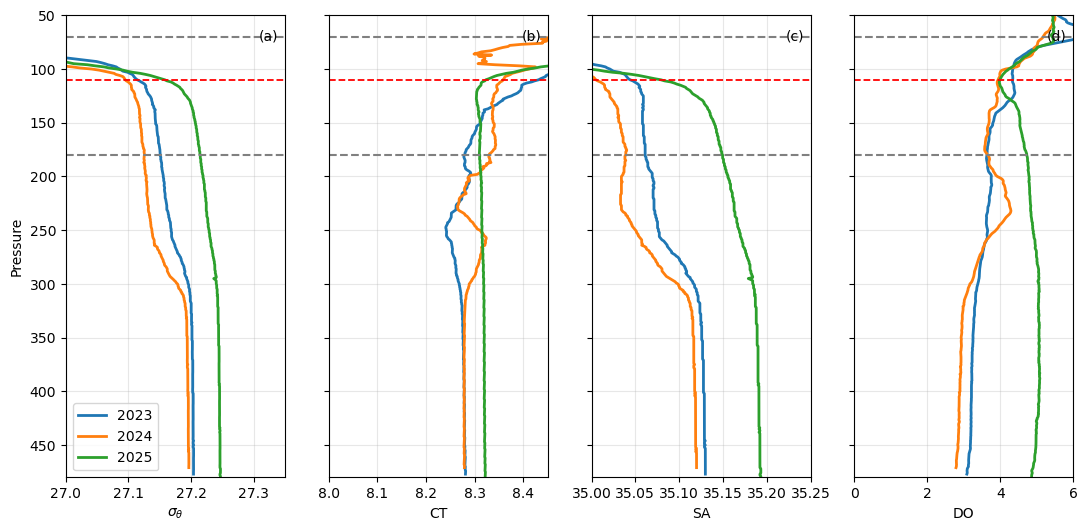

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gsw

# =========================
# 1. File paths and station settings
# =========================
data_dir = Path(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy")
fig_dir = Path(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures")
fig_dir.mkdir(parents=True, exist_ok=True)

files = {
    "2023": ("GOS2023001013.npy", 446),
    "2024": ("GOS2024001014.npy", 519),
    "2025": ("GOS2025001014.npy", 736),
}

sill_depths = [70, 180]

analysis_lines = {
    110: {"color": "red", "linestyle": "--"},
}

# =========================
# 2. Read one station profile
# =========================
def load_station_profile(file_path, station_id):

    D = np.load(file_path, allow_pickle=True).item()

    prof = D[station_id]

    P  = np.asarray(prof["P"], dtype=float)
    T  = np.asarray(prof["T"], dtype=float)
    SP = np.asarray(prof["S"], dtype=float)
    OX = np.asarray(prof["OX"], dtype=float)

    lon = float(prof["LON"])
    lat = float(prof["LAT"])

    good = np.isfinite(P) & np.isfinite(T) & np.isfinite(SP) & np.isfinite(OX)

    P  = P[good]
    T  = T[good]
    SP = SP[good]
    OX = OX[good]

    idx = np.argsort(P)

    P  = P[idx]
    T  = T[idx]
    SP = SP[idx]
    OX = OX[idx]

    SA = gsw.SA_from_SP(SP, P, lon, lat)
    CT = gsw.CT_from_t(SA, T, P)

    sigma0 = gsw.sigma0(SA, CT)

    rho = gsw.rho(SA, CT, P)
    rho_kgL = rho / 1000.0

    O_mean_raw = np.nanmean(OX)

    if O_mean_raw < 20:
        DO_mLL = OX
    else:
        DO_mLL = OX * rho_kgL / 44.66

    return {
        "P": P,
        "sigma0": sigma0,
        "CT": CT,
        "SA": SA,
        "DO_mLL": DO_mLL,
    }


# =========================
# 3. Read all profiles
# =========================
profiles = {}

for label, (fname, st) in files.items():

    file_path = data_dir / fname

    profiles[label] = load_station_profile(file_path, st)


# =========================
# 4. layer mean function
# =========================
def layer_mean(P, X, zmin=None, zmax=None):

    mask = np.isfinite(P) & np.isfinite(X)

    if zmin is not None:
        mask &= (P >= zmin)

    if zmax is not None:
        mask &= (P < zmax)

    return np.nanmean(X[mask])


def diff_dict(d):

    yrs = sorted(d.keys())

    out = {}

    for i in range(1, len(yrs)):

        out[f"{yrs[i]}-{yrs[i-1]}"] = d[yrs[i]] - d[yrs[i-1]]

    return out


# =========================
# 5. compute layer means
# =========================

sigma_110_300 = {}
sigma_300_bottom = {}
sigma_110_bottom = {}

SA_110_bottom = {}
SA_110_300 = {}

for yr, prof in profiles.items():

    P = prof["P"]

    sigma_110_300[yr] = layer_mean(P, prof["sigma0"], 110, 300)

    sigma_300_bottom[yr] = layer_mean(P, prof["sigma0"], 300, None)

    sigma_110_bottom[yr] = layer_mean(P, prof["sigma0"], 110, None)

    SA_110_bottom[yr] = layer_mean(P, prof["SA"], 110, None)

    SA_110_300[yr] = layer_mean(P, prof["SA"], 110, 300)


sigma_110_300_change = diff_dict(sigma_110_300)
sigma_300_bottom_change = diff_dict(sigma_300_bottom)
sigma_110_bottom_change = diff_dict(sigma_110_bottom)

SA_110_bottom_change = diff_dict(SA_110_bottom)
SA_110_300_change = diff_dict(SA_110_300)


# =========================
# 6. requested specific changes
# =========================

DO_110_bottom_2024 = layer_mean(
    profiles["2024"]["P"],
    profiles["2024"]["DO_mLL"],
    110,
    None
)

DO_110_bottom_2025 = layer_mean(
    profiles["2025"]["P"],
    profiles["2025"]["DO_mLL"],
    110,
    None
)

DO_110_bottom_change_25_24 = (
    DO_110_bottom_2025 - DO_110_bottom_2024
)


DO_200_250_2023 = layer_mean(
    profiles["2023"]["P"],
    profiles["2023"]["DO_mLL"],
    200,
    250
)

DO_200_250_2024 = layer_mean(
    profiles["2024"]["P"],
    profiles["2024"]["DO_mLL"],
    200,
    250
)

DO_200_250_change_24_23 = (
    DO_200_250_2024 - DO_200_250_2023
)


CT_230_300_2023 = layer_mean(
    profiles["2023"]["P"],
    profiles["2023"]["CT"],
    230,
    300
)

CT_230_300_2024 = layer_mean(
    profiles["2024"]["P"],
    profiles["2024"]["CT"],
    230,
    300
)

CT_230_300_change_24_23 = (
    CT_230_300_2024 - CT_230_300_2023
)


# 新增：23–24 年 110–300 盐度变化
SA_110_300_change_24_23 = (
    SA_110_300["2024"] - SA_110_300["2023"]
)


# =========================
# 7. print results
# =========================

print("\n==============================")

print("sigma0")

print("==============================")

print("\n110-300")

for k in sigma_110_300:
    print(k, sigma_110_300[k])

print("change")
print(sigma_110_300_change)


print("\n300-bottom")

for k in sigma_300_bottom:
    print(k, sigma_300_bottom[k])

print("change")
print(sigma_300_bottom_change)


print("\n110-bottom")

for k in sigma_110_bottom:
    print(k, sigma_110_bottom[k])

print("change")
print(sigma_110_bottom_change)



print("\n==============================")

print("SA")

print("==============================")

print("\n110-bottom")

for k in SA_110_bottom:
    print(k, SA_110_bottom[k])

print("change")
print(SA_110_bottom_change)


print("\n110-300")

for k in SA_110_300:
    print(k, SA_110_300[k])

print("\n23-24 change 110-300 SA")

print(SA_110_300_change_24_23)



print("\n==============================")

print("specific changes")

print("==============================")

print("DO 110-bottom 25-24")

print(DO_110_bottom_change_25_24)

print("\nDO 200-250 24-23")

print(DO_200_250_change_24_23)

print("\nCT 230-300 24-23")

print(CT_230_300_change_24_23)



# =========================
# 8. plot
# =========================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(13,6),
    sharey=True
)

panel_info = [

    ("sigma0", r"$\sigma_\theta$", (27.0,27.35)),

    ("CT", "CT", (8,8.45)),

    ("SA", "SA", (35,35.25)),

    ("DO_mLL", "DO", (0,6))
]


for ax, (var, label, xlim) in zip(
        axes,
        panel_info
):

    for yr, prof in profiles.items():

        ax.plot(
            prof[var],
            prof["P"],
            linewidth=2,
            label=yr
        )

    for sd in sill_depths:

        ax.axhline(
            sd,
            linestyle="--",
            color="gray"
        )


    for d, style in analysis_lines.items():

        ax.axhline(
            d,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=1.3
        )


    ax.set_xlim(xlim)

    ax.set_xlabel(label)

    ax.invert_yaxis()

    ax.grid(alpha=0.3)


axes[0].set_ylim(480,50)

axes[0].set_ylabel("Pressure")


axes[0].legend()


for ax, lab in zip(
        axes,
        ["(a)","(b)","(c)","(d)"]
):

    ax.text(
        0.97,
        0.97,
        lab,
        transform=ax.transAxes,
        ha="right",
        va="top"
    )


plt.savefig(
    fig_dir/"profiles_2023_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()